# Extra — DEM elevation contours → H3 coverage tiers (Bay Area)

**A complete DEM download → land mask → elevation isobands → product-native H3 indexing → cumulative coverage tiers → per-tier rasterize → multi-band stack pipeline,
demonstrated on the USGS 3DEP seamless (10 m) DEM over the San Francisco Bay Area.**

## Where this fits

This is a self-contained **extra** in the wireless-coverage series. The main notebooks build canopy and
surface models from a raw LiDAR point cloud; this one takes the complementary path — a ready-made **10 m
seamless elevation raster** — and walks the full GeoBrix raster→grid pipeline (`rst_clip` → `rst_isoband`
→ product H3 → `rst_h3_rasterize_agg` → `rst_frombands_agg`). It stands alone: no LiDAR required.

## What this notebook shows

The Bay Area spans sea level at the Bay and Pacific coast up through the San Francisco hills
(Twin Peaks ≈280 m) to the Peninsula and East Bay ridgelines (≈600–700 m). That ≈700 m spread
produces twelve meaningful 60 m elevation bands across the AOI.

This pipeline produces **two complementary views**:

1. **Interval elevation-band map** — which single elevation band (e.g. 150–200 m) each H3 cell falls in.
   Useful for inspecting band geometry and cell coverage.
2. **Cumulative-tier depth map** — how many elevation thresholds each location clears.
   Tier T = "elevation ≥ BREAKS[T]"; a cell in band *i* belongs to tiers 0…*i*, so depth climbs
   with terrain height — the **telco nested-coverage model** applied to elevation.

**Pipeline steps:**

1. **Download a DEM** — `DemDownloader().download(BAY_BBOX, DEM_DIR, resolution="finest")` fetches the
   USGS **3DEP seamless (10 m)** DEM windowed to the Bay Area AOI via the Planetary Computer STAC
   API, staged to a UC Volume (idempotent). `FORCE_RELOAD=False` skips the download on re-runs.
2. **Download a land mask** — `OvertureClient().discover(BAY_BBOX, themes=["base"])` fetches Overture Maps **base/water**
   features; subtracting them from the AOI box yields a **land multipolygon** (EPSG:4326). This masks Bay and Pacific
   pixels to NoData at the source before any raster processing — essential over a water-heavy AOI.
3. **Read as tiled Spark rows** — the `raster_gbx` reader with `tileSize=512` splits each GeoTIFF into 512×512-px
   **virtual tiles** (bytes-free path + window — the memory-efficient GeoBrix default). `rst_clip` then masks each
   tile to the land polygon (`cutline_all_touched=True`). The seamless product is already EPSG:4326, so no reprojection is needed.
4. **Extract elevation isobands** — `rx.rst_isoband("tile", breaks)` with 60 m breaks (0, 60, …, 720)
   produces **12 contiguous band polygons** as a distributed Spark column of WKB geometry.
5. **H3 indexing via Databricks product H3** — [`h3_try_coverash3`](https://docs.databricks.com/aws/en/sql/language-manual/functions/h3_try_coverash3)
   (overlap) fills each band polygon at **H3 resolution 9** (≈174 m edge), producing solid, gap-free H3 cells per band.
   Fully distributed — no driver-side h3-py.
6. **Cumulative coverage tiers** — from `(band_level, cellid)` pairs, derive tiers where tier T = union
   of all cells with band_level ≥ T. A cell in band *i* belongs to tiers 0…*i*, so coverage depth
   climbs with elevation — the telco nested-coverage model.
7. **Shared grid spec** — `rx.rst_h3_gridspec` snaps a single pixel-aligned canvas over all bands combined.
8. **Per-tier rasterize** — `rx.rst_h3_rasterize_agg` burns each cumulative tier's H3 cells onto the
   shared canvas. `FORCE_RELOAD=False` reuses a materialized temp table for fast re-runs.
9. **Stack** — `rx.rst_frombands_agg` assembles per-tier tiles into a single multi-band GeoTIFF;
   `plot_raster(composite="depth")` shows a real 1..N gradient — the number of elevation thresholds
   each pixel clears (coastal = 1, ridgelines = 12).

> **Resolution note:** H3 res 9 (≈174 m edge) suits this AOI-scale terrain view. Precision use
> cases at res 13–15 (≈10 m–1 m) pair naturally with the 1–2 m LiDAR surfaces built in the main
> series notebooks.

## Runtime requirement

Run on **Databricks Serverless environment 5** (or any cluster with UC Volumes access). This notebook
uses the [lightweight execution tier](https://databrickslabs.github.io/geobrix/docs/api/execution-tiers) — no
JAR or GDAL init script required. See the [GeoBrix API overview](https://databrickslabs.github.io/geobrix/docs/api/overview)
for the full function reference. Outputs are empty until executed on a cluster.

---
**Last Update:** September 18, 2026


![H3 Rasterize — DEM isobands to a multi-band H3 raster stack](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/diagrams/h3-rasterize/h3-rasterize.png)

## Install GeoBrix

The lightweight `[light_env5,stac,vizx,overture]` extras are sufficient — no JAR or GDAL init script
required (when using the lightweight tier). The notebook targets **Serverless environment 5**.

In [0]:
%pip install --quiet --disable-pip-version-check --no-deps --force-reinstall "geobrix[light_env5,stac,vizx,overture] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"
%pip install --quiet "geobrix[light_env5,stac,vizx,overture] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

## Imports and registration

In [0]:
import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import functions as F

# GeoBrix lightweight tier — runs on Serverless.
from databricks.labs.gbx.pyrx import functions as rx
from databricks.labs.gbx.pygx import functions as gx   # grid functions (h3_cellfill, ...)
from databricks.labs.gbx.ds.register import register
from databricks.labs.gbx.vizx import plot_file, plot_raster, plot_static, plot_mask_layers, cells_as_gdf, grid_as_gdf

# Register pyrx SQL UDFs and H3 UDTFs (rst_h3_rastertogridavg, etc.).
rx.register(spark)
gx.register(spark)   # registers gbx_h3_cellfill (used in the fill-missing-cells option below)
register(spark)


def _persist(df, name):
    """Write a DataFrame to a PERMANENT table you own
    (``CATALOG.SCHEMA.TABLE_PREFIX_<name>``) and return it read back, so downstream
    cells read stored tiles instead of recomputing. ``FORCE_RELOAD`` rebuilds; else an
    existing table is reused. Permanent tables persist across sessions."""
    tbl = f"{CATALOG}.{SCHEMA}.{TABLE_PREFIX}_{name}"
    if FORCE_RELOAD or not spark.catalog.tableExists(tbl):
        df.write.mode("overwrite").saveAsTable(tbl)
    return spark.table(tbl)

In [0]:
INTERACTIVE_PLOTS = False  # set True for interactive MapLibre maps

## DEM path and parameters

[`DemDownloader`](https://databrickslabs.github.io/geobrix/docs/sample-data/dem-downloader) wraps the **USGS 3DEP** dataset hosted on Microsoft Planetary Computer.
The default `DemDownloader()` selects the **3DEP seamless** product — full, gap-free coverage across the US.
With `resolution="finest"` it queries the finest seamless tier (**10 m** over 30 m) intersecting `BAY_BBOX`,
downloads the tiles, and writes GeoTIFF files to `DEM_DIR` in the UC Volume — idempotent on repeat runs.
The seamless product is delivered in **EPSG:4326**, so no reprojection is needed downstream. See the
[DEM downloader reference](https://databrickslabs.github.io/geobrix/docs/sample-data/dem-downloader) for all download options and supported datasets.


In [0]:
# --- area & output ---
BAY_BBOX = (-122.55, 37.45, -121.95, 37.95)          # San Francisco Bay Area (lon/lat)
DEM_DIR  = "/Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/elevation-3dep/dem_10m"  # 10 m 3DEP seamless
LAND_DIR = "/Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/overture-water-bay"      # Overture base/water over the Bay AOI (for the land mask)

# --- persistence: the per-tier rasterized tiles are written to a PERMANENT table you own ---
CATALOG      = "geospatial_docs"                     # <- set to a catalog you can write to
SCHEMA       = "geobrix"                             # <- set to a schema you can write to
TABLE_PREFIX = "wc_dem"                              # table: <CATALOG>.<SCHEMA>.wc_dem_tier_tiles

# --- parameters ---
H3_RESOLUTION = 9                                    # ≈174 m edge — scaled to the 50+ km Bay AOI (precision wants 13-15; pair with LiDAR)
TILE_PX       = 512                                  # reader splits the DEM into 512×512-px virtual tiles (distributed)
BAND_STEP_M   = 60
BREAKS        = [float(b) for b in range(0, 721, BAND_STEP_M)]   # 0,60,...,720 -> 12 bands
FORCE_RELOAD  = False  # True → re-download + rebuild materialized tables; False → reuse staged/cached artifacts (fast re-runs).

# shared H3 canvas pixel size: ≈3 px per res-9 hex edge (≈174 m) at Bay Area latitude
import math
_EDGE_M = 174.4
PIXEL_SIZE_DEG = (_EDGE_M / 3.0) / (111320.0 * math.cos(math.radians(37.7)))
print(f"H3 res {H3_RESOLUTION} | breaks {BREAKS} | pixel {PIXEL_SIZE_DEG:.7f} deg")


H3 res 9 | breaks [0.0, 60.0, 120.0, 180.0, 240.0, 300.0, 360.0, 420.0, 480.0, 540.0, 600.0, 660.0, 720.0] | pixel 0.0006600 deg


### Stage the 3DEP seamless DEM

`DemDownloader().download(BAY_BBOX, DEM_DIR, resolution="finest")` queries the Planetary Computer
STAC for USGS **3DEP seamless (10 m)** tiles intersecting `BAY_BBOX`, downloads them, and writes the result to
the Volume — **once, idempotent** (skips files that already exist). The seamless product gives full,
gap-free coverage over the AOI (EPSG:4326). Safe on Serverless: uses rasterio's bundled GDAL, no CLI tools
required. See the [DEM downloader reference](https://databrickslabs.github.io/geobrix/docs/sample-data/dem-downloader) for all download options and supported datasets.


In [0]:
from databricks.labs.gbx.sample.dem import DemDownloader
import glob
# 3DEP seamless (10 m) — full, gap-free coverage over the Bay Area AOI, delivered in EPSG:4326.
dem = DemDownloader()                                # default collection: 3dep-seamless
existing = glob.glob(f"{DEM_DIR}/**/*.tif", recursive=True)
if FORCE_RELOAD or not existing:
    meta = dem.download(BAY_BBOX, DEM_DIR, resolution="finest")   # live: Planetary Computer STAC; "finest" = 10 m
    meta.select("item_id", "out_file_path", "out_file_sz", "is_out_file_valid").show(truncate=False)
else:
    print(f"DEM already staged ({len(existing)} tile(s)) under {DEM_DIR} — skipping download (FORCE_RELOAD=False).")


DEM already staged (2 tile(s)) under /Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/elevation-3dep/dem_10m — skipping download (FORCE_RELOAD=False).


### Render the DEM

The `raster_gbx` reader returns **virtual tiles** — bytes-free path + window structs, one 512×512-px
chunk per row. VizX [`plot_raster`](https://databrickslabs.github.io/geobrix/docs/api/vizx) can render a
virtual tile directly, but a single chunk is only a slice of the DEM. To preview the whole staged footprint
we render an entire staged GeoTIFF via [`plot_file`](https://databrickslabs.github.io/geobrix/docs/api/vizx)
(auto-decimation + percentile stretch, `cmap="terrain"`). The seamless product is full-coverage, so any
staged tile shows continuous terrain across its AOI window.


2 staged tile(s) under /Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/elevation-3dep/dem_10m; previewing data_n38w122-13.tif


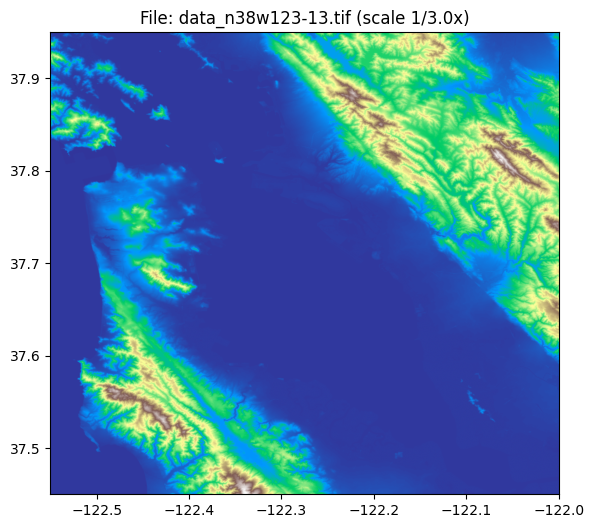

In [0]:
# Preview the staged DEM. The seamless product is full-coverage, so we render an entire staged
# GeoTIFF via plot_file (auto-decimation + percentile stretch). If the AOI spans more than one
# seamless tile, the first staged tile is representative.
import glob

dem_tifs = sorted(glob.glob(f"{DEM_DIR}/**/*.tif", recursive=True))
if not dem_tifs:
    raise FileNotFoundError(f"No .tif staged under {DEM_DIR}; run the download cell first.")
print(f"{len(dem_tifs)} staged tile(s) under {DEM_DIR}; previewing {dem_tifs[0].split('/')[-1]}")
plot_file(dem_tifs[1], fig_w=8, fig_h=6, cmap="terrain")


### Download a land mask (Overture Maps)

A bare-earth DEM has no clean water encoding, so we bring an authoritative land vector. **`OvertureClient`** (`databricks.labs.gbx.sample.overture`) fetches Overture Maps **base/water** features for the AOI; we union them and subtract from the AOI box to get a **land** multipolygon. That polygon becomes the `rst_clip` cutline in the next step — masking the Bay and Pacific to NoData at the source. This step is idempotent (`FORCE_RELOAD`).

In [0]:
from databricks.labs.gbx.sample.overture import OvertureClient
from shapely import wkb as _wkb
from shapely.geometry import box as _box
from shapely.ops import unary_union
import glob as _glob

ov = OvertureClient()
if FORCE_RELOAD or not _glob.glob(f"{LAND_DIR}/**/*.parquet", recursive=True):
    assets = ov.discover(BAY_BBOX, themes=["base"]).filter(F.col("type") == "water")
    ov.download(assets, LAND_DIR, bbox=BAY_BBOX)      # distributed, Serverless-safe
water = ov.read(LAND_DIR, theme="base", type="water", bbox=BAY_BBOX)
_wg = [_wkb.loads(bytes(r["geometry"])) for r in water.select("geometry").collect()]
W, S, E, N = BAY_BBOX
land_geom = _box(W, S, E, N).difference(unary_union(_wg)) if _wg else _box(W, S, E, N)
land_wkb  = land_geom.wkb                             # EPSG:4326 land multipolygon (WKB)
print(f"land mask: subtracted {len(_wg)} water feature(s); land area frac ≈ {land_geom.area / _box(W,S,E,N).area:.2f}")

land mask: subtracted 15448 water feature(s); land area frac ≈ 0.67


## Step 1 — Load DEM and extract elevation isobands

**Read as virtual tiles (distributed):** the `raster_gbx` reader with `tileSize=512` splits each GeoTIFF into
512×512-px **virtual tiles** — bytes-free structs (path + window), the memory-efficient GeoBrix default. One Spark
row per tile; the 10 m DEM is processed in parallel across executors. The seamless product is already
**EPSG:4326**, matching the land cutline and the lon/lat product-H3 indexing — no reprojection needed.

**Clip to land (`rst_clip`):** each virtual tile is masked to the land multipolygon derived from Overture, setting
Bay and Pacific pixels to NoData before any further processing.

**Isobands on land-only tiles:** `rx.rst_isoband("tile", breaks)` (see [RasterX functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions)) runs as a **distributed Spark column
expression** — each executor processes one clipped tile and emits rows of
`(band_level, geom_wkb, elev_lo, elev_hi)` for every contiguous elevation band.

With 60 m breaks from 0 to 720 m, the Bay Area DEM yields **12 elevation bands**: from sea-level coastal
areas through the mid-slope neighborhoods up to the Peninsula and East Bay ridgelines. Each row's
`geom_wkb` column holds the polygon as **WKB BINARY** — the native input format for Databricks
product H3 functions in the next step.


In [0]:
# Read the seamless DEM as virtual tiles: the raster_gbx reader with tileSize=512 splits each
# GeoTIFF into 512×512-px virtual tiles (bytes-free path + window — the memory-efficient
# GeoBrix default), one Spark row per tile, processed in parallel across executors.
tiles = (spark.read.format("raster_gbx")
         .option("tileSize", str(TILE_PX))
         .load(DEM_DIR))
n_tiles = tiles.count()
# The 3DEP seamless product is delivered in EPSG:4326 — the same CRS as the land cutline and the
# lon/lat product-H3 indexing — so no rst_transform reprojection is needed here.
tiles = tiles.select("source", "tile")
print(f"DEM read as {n_tiles} virtual tiles ({TILE_PX}×{TILE_PX} px each), EPSG:4326")


DEM read as 154 virtual tiles (512×512 px each), EPSG:4326


### Clip the tiles to land (`rst_clip`)

GeoBrix **[`rst_clip`](https://databrickslabs.github.io/geobrix/docs/api/raster-functions)** masks each virtual tile to the land polygon: everything outside the cutline becomes NoData, so `rst_isoband` never emits water bands. `cutline_all_touched=True` keeps pixels the boundary touches; `clip_crs` defaults to the raster CRS (land and DEM are both EPSG:4326, so no reprojection). `rst_clip` reads virtual tiles directly — no materialization needed.

In [0]:
dem_land = tiles.select("source",
                        rx.rst_clip("tile", F.lit(land_wkb), F.lit(True)).alias("tile"))

In [0]:
breaks_arr = F.array(*[F.lit(b) for b in BREAKS])
patches = (dem_land
    .select(F.explode(rx.rst_isoband("tile", breaks_arr)).alias("p"))
    .select(F.col("p.band").alias("band_level"),
            F.col("p.geom_wkb").alias("geom_wkb"),
            F.col("p.lower").alias("elev_lo"),
            F.col("p.upper").alias("elev_hi")))
patches.groupBy("band_level", "elev_lo", "elev_hi").count().orderBy("band_level").show()

+----------+-------+-------+-----+
|band_level|elev_lo|elev_hi|count|
+----------+-------+-------+-----+
|         0|    0.0|   60.0|  577|
|         1|   60.0|  120.0|  817|
|         2|  120.0|  180.0|  884|
|         3|  180.0|  240.0|  720|
|         4|  240.0|  300.0|  625|
|         5|  300.0|  360.0|  426|
|         6|  360.0|  420.0|  263|
|         7|  420.0|  480.0|  145|
|         8|  480.0|  540.0|   89|
|         9|  540.0|  600.0|   42|
|        10|  600.0|  660.0|   14|
|        11|  660.0|  720.0|    2|
+----------+-------+-------+-----+



GeoBrix **[`rst_isoband`](https://databrickslabs.github.io/geobrix/docs/api/raster-functions)** emits `geom_wkb` as **WKB BINARY** — the exact format Databricks product H3 functions
accept. The hand-off from GeoBrix geometry to Databricks H3 indexing uses the **product Python
bindings** (`pyspark.databricks.sql.functions`):

```python
from pyspark.databricks.sql import functions as DBF
h3_index = DBF.h3_try_coverash3   # every H3 cell that overlaps the polygon — solid, gap-free bands
```

Product's **[`h3_try_coverash3`](https://docs.databricks.com/aws/en/sql/language-manual/functions/h3_try_coverash3)** (a Databricks built-in) returns every H3 cell that **overlaps** the polygon, ensuring
solid, gap-free bands across the SF terrain. The `h3_try_*` prefix returns NULL for degenerate
patches instead of failing the job.

> **WKB, not GEOMETRY.** The product H3 functions accept WKB BINARY and **reject the GEOMETRY type** —
> do not wrap `geom_wkb` in `ST_GeomFromWKB`.

Both `rst_isoband` (Step 1) and the H3 indexing run as **distributed Spark
expressions** — no driver-side `h3.polygon_to_cells`, no `collect()`. This is the GeoBrix →
Databricks-native H3 on-ramp: GeoBrix extracts the geometry; the Databricks platform handles
spatial indexing at scale.

In [0]:
# Hand off to Databricks-native H3 via the product Python bindings. rst_isoband emits
# WKB, which the H3 functions accept directly (no ST_GeomFromWKB). The h3_try_* variants
# return NULL instead of erroring on a bad/degenerate patch, so one sliver can't fail the
# whole job. Fully distributed — no driver-side H3 indexing.
from pyspark.databricks.sql import functions as DBF

h3_index = DBF.h3_try_coverash3
cells_df = (
    patches
    .select(
        "band_level",
        F.explode(h3_index(F.col("geom_wkb"), F.lit(H3_RESOLUTION))).alias("cellid"),
    )
    .where(F.col("cellid").isNotNull())
    .distinct()
)
cells_df.groupBy("band_level").count().orderBy("band_level").show()

+----------+-----+
|band_level|count|
+----------+-----+
|         0|10184|
|         1| 4809|
|         2| 5594|
|         3| 5191|
|         4| 4095|
|         5| 2711|
|         6| 1550|
|         7|  881|
|         8|  440|
|         9|  121|
|        10|   30|
|        11|    2|
+----------+-----+



### Cumulative coverage tiers: interval bands → nested depth model

GeoBrix `rst_isoband` produces **disjoint** elevation intervals — each pixel belongs to exactly one band —
so stacking the 12 per-band rasters gives a coverage depth of ≈ 1 everywhere (one flat colour,
no gradient). To get a meaningful depth signal we convert to **cumulative tiers**:

- **Tier T** = "elevation ≥ `BREAKS[T]`" = union of all interval bands ≥ T
- A cell in interval band *i* therefore belongs to tiers *0 … i*
- **Coverage depth** (# tiers covering a pixel) climbs with elevation — low coastal terrain hits
  one threshold; the highest ridgelines clear all twelve

This mirrors the **telco nested-coverage model** — a site covered by three operators is counted once
per operator, and the depth map shows which areas have the most options. Here, "operators" are
elevation thresholds and "coverage" is terrain height.

In [0]:
# Cumulative coverage tiers: tier T = "elevation >= breaks[T]" = union of interval bands >= T.
# A cell in interval band i belongs to tiers 0..i, so coverage DEPTH (# tiers covering a
# pixel) climbs with elevation — the telco nested-coverage model.
tiers_df = (
    cells_df
    .select("cellid", F.explode(F.sequence(F.lit(0), F.col("band_level"))).alias("tier"))
    .distinct()
)
tiers_df.groupBy("tier").count().orderBy("tier").show()

+----+-----+
|tier|count|
+----+-----+
|   0|19632|
|   1|11436|
|   2| 9384|
|   3| 7158|
|   4| 5059|
|   5| 3152|
|   6| 1705|
|   7|  921|
|   8|  448|
|   9|  122|
|  10|   30|
|  11|    2|
+----+-----+



### Render the H3 cells

`plot_static` draws the H3 cells straight from the Spark DataFrame: with
`grid_system="h3"` it turns each `cellid` into its hexagon boundary and colours it by
elevation band, over a basemap (also can plot geoms). With the default `coveras` mode the
bands form solid, contiguous fills — no white gaps between hexagons. Each cell keeps its own geometry, so this per-cell view
is handy for inspecting individual hexagons at this data size. It renders as a static
image (so it shows on GitHub and the docs site); for an interactive pan/zoom map, pass the
same Spark DataFrame to `vizx.plot_interactive(cells_df, grid_system="h3", column="band_level")`
— it handles scale (falling back to a raster overlay for very large cell sets) and renders
inline in Databricks.

__Note:__ for much larger cell sets, dissolve first —
`cells_as_gdf(cells_df, "cellid", extra_cols=["band_level"], dissolve_by="band_level")`
merges each band into a single footprint polygon (far fewer geometries to render), then
pass that GeoDataFrame to `plot_static`. (`plot_static` itself renders one hexagon per
cell; dissolving lives on the `cells_as_gdf` adapter.)

> **Gaps here can be filled** with GeoBrix `h3_cellfill` — demonstrated in the **Cumulative Tier
> Overlay** section below, on the per-cell coverage-**depth** surface (where each `cellid` is unique,
> so the fill has nothing to collapse). It is deliberately *not* applied to this interval-band
> surface: with `coveras` a cell can belong to several adjacent bands, so a `cellid` repeats and a
> value-per-cell fill would collapse those duplicates.

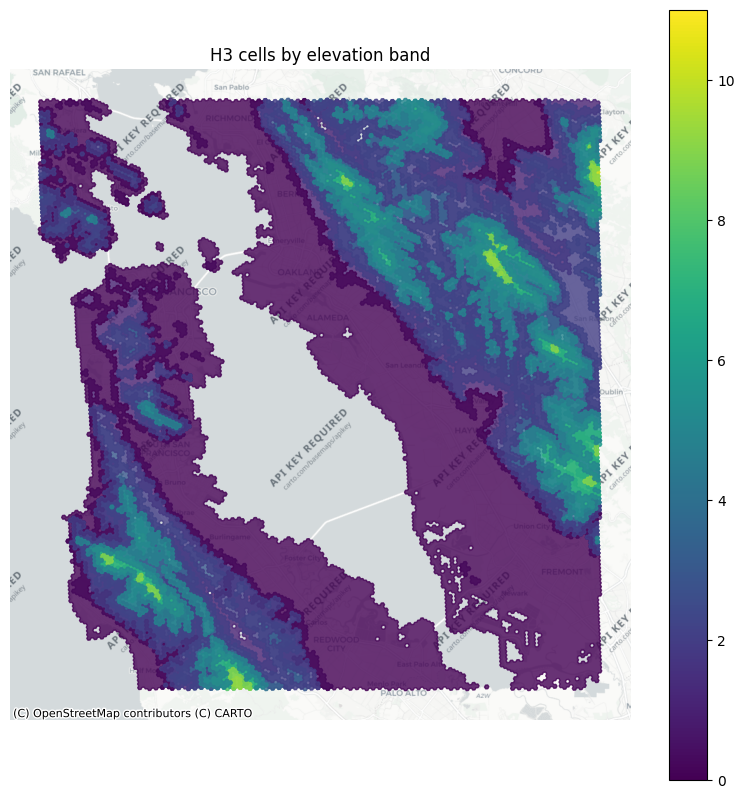

In [0]:
# Dissolve per-cell hexagons into one footprint polygon per band before rendering.
# cells_as_gdf with dissolve_by="band_level" merges each band into one polygon, so
# plot_static receives at most 12 rows instead of ~13–18k hex boundaries.
# dissolve_engine="product": use the product-coupled dissolve backend.
cells_gdf = cells_as_gdf(cells_df, "cellid", extra_cols=["band_level"], dissolve_by="band_level", dissolve_engine="product")
ax = plot_static(
    cells_gdf,
    column="band_level",
    cmap="viridis",
    title="H3 cells by elevation band",
)

## Step 3 — Shared grid spec via `rst_h3_gridspec`

[`rst_h3_gridspec`](https://databrickslabs.github.io/geobrix/docs/api/raster-functions) computes a pixel-snapped bounding box and pixel dimensions
that span **all** H3 cells across **all** band levels. Because we pass no
grouping column here (we want a single shared canvas), it returns a single-row
DataFrame with a `grid` struct.

Using the same `grid` for every band ensures all per-band tiles are spatially
aligned — a prerequisite for `rst_frombands_agg` to produce a coherent stack.

In [0]:
# Compute the shared canvas over ALL cells (no grouping column → one grid row).
grid_df = rx.rst_h3_gridspec(cells_df, "cellid", pixel_size=PIXEL_SIZE_DEG)
grid_row = grid_df.first()
g = grid_row["grid"]

print("Shared canvas grid spec:")
print(f"  xmin={g['xmin']:.6f}  ymin={g['ymin']:.6f}")
print(f"  xmax={g['xmax']:.6f}  ymax={g['ymax']:.6f}")
print(f"  pixel_size={g['pixel_size']:.6f}")
print(f"  width={g['width']}  height={g['height']}  srid={g['srid']}")

# Broadcast the grid constants to all rows so rst_h3_rasterize_agg
# receives the same extent per group.
cells_with_grid = cells_df.withColumn("xmin",   F.lit(g["xmin"]))\
                           .withColumn("ymin",   F.lit(g["ymin"]))\
                           .withColumn("xmax",   F.lit(g["xmax"]))\
                           .withColumn("ymax",   F.lit(g["ymax"]))\
                           .withColumn("width",  F.lit(g["width"]))\
                           .withColumn("height", F.lit(g["height"]))

# Same broadcast to tiers_df for per-tier rasterize.
tiers_with_grid = tiers_df.withColumn("xmin",   F.lit(g["xmin"]))\
                           .withColumn("ymin",   F.lit(g["ymin"]))\
                           .withColumn("xmax",   F.lit(g["xmax"]))\
                           .withColumn("ymax",   F.lit(g["ymax"]))\
                           .withColumn("width",  F.lit(g["width"]))\
                           .withColumn("height", F.lit(g["height"]))

Shared canvas grid spec:
  xmin=-122.555931  ymin=37.444547
  xmax=-121.943438  ymax=37.955398
  pixel_size=0.000660
  width=928  height=774  srid=4326


### Render the shared canvas over the cells
  
`rst_h3_gridspec` returns the shared raster canvas — the bounding rectangle (and
pixel grid) every per-band raster aligns to. Drawing that rectangle over the cells
shows the extent the H3 cells get binned into: we render the cells with
`plot_static`, then overlay the canvas outline on the same axes.

`plot_static` reprojects layers to Web Mercator (EPSG:3857) so they line up with
the basemap, so the boundary overlay is reprojected to match before drawing.

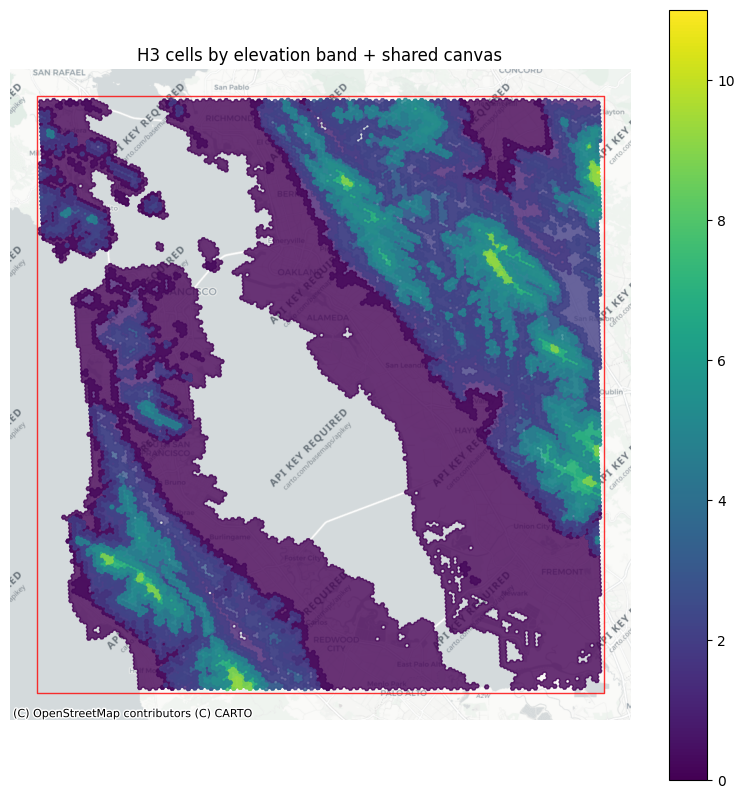

In [0]:
# Multi-layer (static): per-band H3 footprints + the shared-canvas rectangle on
# one matplotlib axes, over a basemap. Static so it renders on GitHub + the docs (see
# the note above); for an interactive pan/zoom map, build GeoDataFrames with
# cells_as_gdf(...) / grid_as_gdf(...) and pass to plot_interactive([vector_layer(...)]).
grid_gdf = grid_as_gdf(g)  # g = grid_row["grid"] -> the shared canvas spec

# Dissolve into one footprint polygon per band.
cells_gdf = cells_as_gdf(cells_df, "cellid", extra_cols=["band_level"], dissolve_by="band_level")

# Cells coloured by elevation band over a basemap, then the shared canvas as a red
# OUTLINE (fill=False so it doesn't cover the cells; basemap=False so it doesn't
# re-fetch tiles). Both layers reproject to 3857 and align.
ax = plot_static(
    cells_gdf,
    column="band_level",
    cmap="viridis",
    title="H3 cells by elevation band + shared canvas",
)
ax = plot_static(grid_gdf, ax=ax, fill=False, edgecolor="red", basemap=False)

## Step 4 — Per-tier rasterize with `rst_h3_rasterize_agg`

[`rst_h3_rasterize_agg`](https://databrickslabs.github.io/geobrix/docs/api/raster-functions) burns a group's H3 cells onto the shared canvas,
producing a presence mask (1.0 where a cell's centroid falls, NoData elsewhere).
Supplying the explicit extent from `rst_h3_gridspec` guarantees every per-tier
tile has identical pixel dimensions — which is required for stacking.

We group by `tier` so each of the **12 cumulative elevation thresholds** produces one
pixel-aligned tile: tier 0 = "elevation ≥ 0 m" (covers the full AOI), tier 11 = "elevation ≥ 660 m"
(only the highest East Bay / Peninsula ridgelines).

Because the per-pixel rasterize is expensive and we read these tiles again in the next two steps, we
**persist them to a permanent table** you own (`CATALOG.SCHEMA.wc_dem_tier_tiles`) — written once and
read back. Permanent tables persist across sessions and clusters. `FORCE_RELOAD=False` reuses an
existing table; set it `True` to rebuild.

In [0]:
# One rasterized tile per cumulative tier, all on the shared canvas. Persist to a
# permanent table (write once, reuse) so the stack + viz read stored tiles.
_tiers_tiles = tiers_with_grid.groupBy("tier").agg(
    rx.rst_h3_rasterize_agg(
        "cellid",
        xmin="xmin",
        ymin="ymin",
        xmax="xmax",
        ymax="ymax",
        width="width",
        height="height",
    ).alias("tile")
)
tier_tiles = _persist(_tiers_tiles, "tier_tiles").orderBy("tier")

print(f"Tier tiles: {tier_tiles.count()} rows -> {CATALOG}.{SCHEMA}.{TABLE_PREFIX}_tier_tiles")
tier_tiles.select("tier",
                  F.expr("gbx_rst_width(tile)    AS px_width"),
                  F.expr("gbx_rst_height(tile)   AS px_height"),
                  F.expr("gbx_rst_numbands(tile) AS numbands")).show()

Tier tiles: 12 rows -> geospatial_docs.geobrix.wc_dem_tier_tiles
+----+--------+---------+--------+
|tier|px_width|px_height|numbands|
+----+--------+---------+--------+
|   0|     928|      774|       1|
|   1|     928|      774|       1|
|   2|     928|      774|       1|
|   3|     928|      774|       1|
|   4|     928|      774|       1|
|   5|     928|      774|       1|
|   6|     928|      774|       1|
|   7|     928|      774|       1|
|   8|     928|      774|       1|
|   9|     928|      774|       1|
|  10|     928|      774|       1|
|  11|     928|      774|       1|
+----+--------+---------+--------+



### Cumulative tier overlay

We render **all cumulative tiers** in a single nested overlay — tier 0 (full AOI, lowest
threshold) drawn first, tier 11 (highest hilltops only) on top — using a sequential `viridis`
colormap. Each tier is labelled `>= X m`, where X is the elevation threshold.

The result reads like a **telco signal-strength heatmap**: the outermost (lowest-elevation) tier
covers the entire AOI and the concentric inner rings shrink progressively toward the highest East Bay
and Peninsula ridgelines. Darker hues mark areas at or above sea level; the brightest inner
ring marks terrain above 660 m.

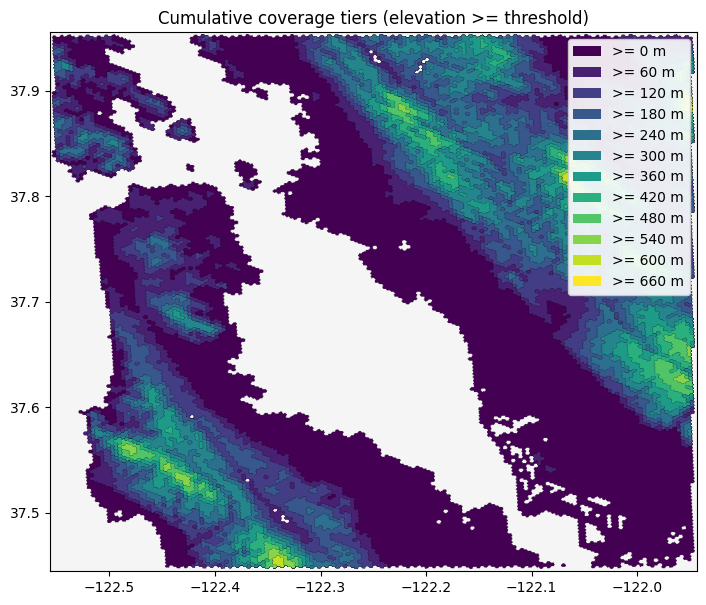

In [0]:
# All cumulative tiers overlaid, tier 0 (largest) first → tier 11 (smallest hilltops) on top.
# Sequential viridis colormap: outer (low) tiers get dark hues, inner (high) tiers get bright.
import matplotlib

tiers_sorted = sorted(r["tier"] for r in tier_tiles.select("tier").distinct().collect())
cmap = matplotlib.colormaps["viridis"]
n = max(len(tiers_sorted) - 1, 1)
layers, colors = [], []
for k, t in enumerate(tiers_sorted):
    row = tier_tiles.filter(F.col("tier") == t).first()
    layers.append((f">= {int(BREAKS[t])} m", row["tile"]["raster"]))
    colors.append(cmap(k / n))

plot_mask_layers(layers, colors=colors, fig_w=9, fig_h=7,
                 title="Cumulative coverage tiers (elevation >= threshold)")

### Option — fill missing cells with GeoBrix `h3_cellfill`

The cumulative tiers give us a **per-cell coverage depth**: how many tiers cover each cell — **one
value per `cellid`**. That uniqueness is exactly what a value-per-cell fill needs. (It is *not* true
of the interval `band_level` surface, where `coveras` places a cell in several adjacent bands, so a
`cellid` repeats — a value-per-cell fill would collapse those duplicates. Depth avoids that entirely.)

Because the DEM was clipped to land in the previous step, the depth surface is **land-only**: water
and out-of-AOI pixels are already NoData, so any gaps the fill encounters are genuine interior
**land** gaps (terrain topology, coverage holes in the LiDAR survey), not ocean cells.

GeoBrix **`h3_cellfill`** (a lightweight-tier grouped aggregator) can *optionally* fill **missing
cells** — cells with no depth value — by interpolating each empty cell's value from its valid
**in-group neighbours within `k` rings**. We keep it strictly **local — `k=1` with inverse-distance
weighting (IDW)** — so a gap adopts only its *immediate* neighbours ("water fills with water"); a gap
with no filled neighbour within one ring stays empty, so the fill never invents coverage.

GeoBrix **`h3_cellfill`** fills NULL-valued cells rather than generating them, so we feed it the present cells
plus their 1-ring neighbours as `NULL`-valued gap candidates. Those neighbours come from Product's
**[`h3_kring`](https://docs.databricks.com/aws/en/sql/language-manual/functions/h3_kring)** (a Databricks
built-in). Shown purely as an **option**; the pipeline works without it.

present=19632  gap_candidates=1598  filled=21230


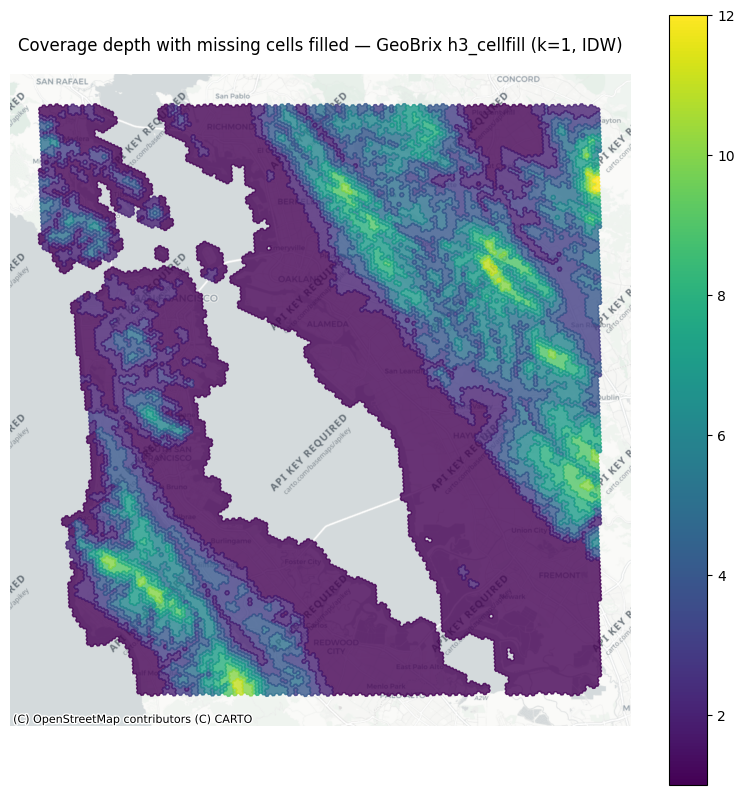

In [0]:
# ── OPTION: fill missing cells with GeoBrix h3_cellfill (k=1, IDW) ──────────────
# Per-cell coverage DEPTH = number of cumulative tiers covering the cell — ONE value
# per cellid (unlike the interval band_level, where coveras repeats a cellid across
# adjacent bands). cellid is unique here, so nothing collapses in the fill.
from pyspark.databricks.sql import functions as DBF
from databricks.labs.gbx.pygx import _cellfill

depth_df = tiers_df.groupBy("cellid").agg(F.count("*").cast("double").alias("depth"))

# Gap candidates = 1-ring neighbours (Product's h3_kring) not already present; feed them
# as (cellid, NULL). GeoBrix h3_cellfill fills each from its in-group neighbours within
# k=1 rings (IDW, power=2). k=1 keeps it strictly local ("water fills with water").
gap = (depth_df.select(F.explode(DBF.h3_kring(F.col("cellid"), F.lit(1))).alias("cellid"))
       .distinct().join(depth_df.select("cellid"), on="cellid", how="left_anti")
       .withColumn("depth", F.lit(None).cast("double")))
fill_in = depth_df.unionByName(gap).withColumn("g", F.lit(1))
payload = fill_in.groupBy("g").agg(
    gx.h3_cellfill("cellid", "depth", F.lit(1), F.lit("idw"), F.lit(2.0)).alias("p")
).first()["p"]
rows = [(int(cid), v) for cid, v in _cellfill.decode(payload) if v is not None]   # drop unfilled gaps
filled_depth = (spark.createDataFrame(rows, "cellid long, depth double")
                .withColumn("depth", F.round("depth").cast("int")))
print(f"present={depth_df.count()}  gap_candidates={gap.count()}  filled={filled_depth.count()}")

# Dissolve by the integer depth (<=~12 groups).
filled_gdf = cells_as_gdf(filled_depth, "cellid", extra_cols=["depth"], dissolve_by="depth")
ax = plot_static(
    filled_gdf,
    column="depth",
    cmap="viridis",
    title="Coverage depth with missing cells filled — GeoBrix h3_cellfill (k=1, IDW)",
)

## Step 5 — Stack tiers with `rst_frombands_agg`

[`rst_frombands_agg`](https://databrickslabs.github.io/geobrix/docs/api/raster-functions) assembles the per-tier tiles into a single multi-band
GeoTIFF, ordered by `tier` ascending. Band *i* in the stacked raster corresponds to
cumulative tier *i* ("elevation ≥ `BREAKS[i]`").

Unlike stacking **interval** bands (which would give depth ≈ 1 everywhere — each pixel covered
by exactly one disjoint band), stacking **cumulative** tiers gives a real gradient: each pixel's
coverage depth equals the **number of elevation thresholds it clears** — low coastal terrain has
depth 1 (only the ≥ 0 m tier covers it) while the highest ridgelines reach depth 12 (every
threshold cleared). `plot_raster(composite="depth")` renders this directly.

In [0]:
# Add a sequential band_index starting at 1 so rst_frombands_agg orders correctly.
from pyspark.sql.window import Window

w = Window.orderBy("tier")
indexed = tier_tiles.withColumn(
    "band_index",
    F.row_number().over(w).cast("int"),
)

# Stack all per-tier tiles into one multi-band tile.
stacked_df = indexed.agg(
    rx.rst_frombands_agg("tile", "band_index").alias("stacked")
)

stacked_row = stacked_df.first()
stacked_tile = stacked_row["stacked"]
print("Stacked tile schema:", stacked_tile.asDict().keys())

# Quick metadata check via SQL accessors.
meta = stacked_df.selectExpr(
    "gbx_rst_numbands(stacked) AS n_bands",
    "gbx_rst_width(stacked)    AS width",
    "gbx_rst_height(stacked)   AS height",
    "gbx_rst_srid(stacked)     AS srid",
).first()
print(f"Bands: {meta['n_bands']}  Width: {meta['width']}  Height: {meta['height']}  SRID: {meta['srid']}")

Stacked tile schema: dict_keys(['cellid', 'raster', 'path', 'path_mode', 'window', 'clip_polygon', 'clip_crs', 'crs', 'metadata'])
Bands: 12  Width: 928  Height: 774  SRID: 4326


### Visualize the stacked multi-band raster — coverage depth

`plot_raster` with `composite="depth"` renders **coverage depth**: the per-pixel count of
cumulative tiers that cover each pixel. Because each tier T = "elevation ≥ BREAKS[T]",
depth is the **number of elevation thresholds the terrain clears**:

- **Depth 1** — coastal and sea-level areas: only the ≥ 0 m tier covers them
- **Depth ≈6** — mid-slope terrain (≈330 m): six thresholds cleared
- **Depth 12** — the highest East Bay / Peninsula ridgelines (≥ 660 m): all twelve thresholds cleared

The result is a viridis gradient rising with elevation — a direct visual proxy for terrain
height. Uncovered pixels (ocean and areas outside the Bay Area AOI) are masked transparent.

This is the **telco nested-coverage model** applied to elevation: depth = how many coverage
tiers overlap at a location. In a real telco deployment each tier would be a different
operator or signal-strength class; here the tiers are elevation thresholds and depth is a
continuous proxy for terrain height.

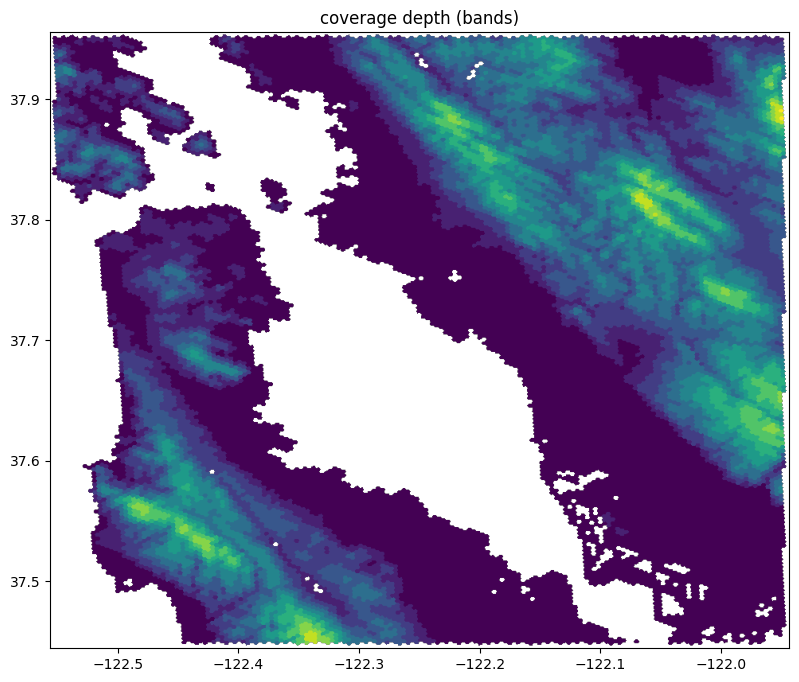

In [0]:
# Render the stacked raster as a coverage-depth map.
# composite="depth" counts, per pixel, how many cumulative tiers cover it → viridis gradient.
# Uncovered pixels (NoData in all tiers) are masked transparent.
plot_raster(stacked_tile["raster"], composite="depth", fig_w=10, fig_h=8)

Multi-layer view: the coverage-depth raster overlaid with H3 cell boundaries by elevation band — pan and zoom to explore the spatial distribution.

In [0]:
if INTERACTIVE_PLOTS:
    from databricks.labs.gbx.vizx import raster_layer, grid_layer, plot_interactive
    plot_interactive([
        raster_layer(stacked_tile["raster"]),
        grid_layer(cells_df, grid_system="h3", cellid_col="cellid", column="band_level", opacity=0.25),
    ])

## Summary

This notebook demonstrated the full H3-cell rasterization pipeline on a Bay Area DEM,
producing **12 elevation bands** (0–720 m, 60 m step) at H3 resolution 9 using the USGS 3DEP
seamless (10 m) DEM, with two complementary views:

> **Function provenance.** `rst_clip`, `rst_isoband`, `rst_h3_*`, and `h3_cellfill` are **GeoBrix** functions;
> `h3_try_coverash3` and `h3_kring` are **Databricks product** (built-in) H3 functions, called via
> the `DBF` (`pyspark.databricks.sql.functions`) binding. `OvertureClient` is a GeoBrix sample-data helper.

**View 1 — Interval elevation-band map** (which single band each area falls in):

| Step | Function | Output |
|---|---|---|
| Download DEM (staged once) | `DemDownloader().download(…)` | GeoTIFF tiles in UC Volume |
| Download land mask (staged once) | `OvertureClient().discover/download/read(…)` | water features → land WKB |
| DEM → virtual tiled rows (Spark) | `raster_gbx` reader (`tileSize=512`) | one Spark row per 512×512-px virtual tile |
| Clip to land (Spark) | GeoBrix `rx.rst_clip` | tiles with Bay/Pacific masked to NoData |
| Land DEM → isobands (Spark) | GeoBrix `rx.rst_isoband` | `(band_level, geom_wkb)` rows |
| Polygon → H3 cells (Spark) | Product [`h3_try_coverash3`](https://docs.databricks.com/aws/en/sql/language-manual/functions/h3_try_coverash3) | `(band_level, cellid)` rows |
| Dissolve + render (viz) | `cells_as_gdf` + `plot_static` | H3 cells coloured by band |

**View 2 — Cumulative-tier depth map** (how many elevation thresholds each location clears):

| Step | Function | Output |
|---|---|---|
| Interval → cumulative tiers | `F.explode(F.sequence(0, band_level))` | `(tier, cellid)` rows |
| Shared canvas (Spark) | GeoBrix `rx.rst_h3_gridspec` | `grid` struct (xmin…height) |
| H3 cells → tile (Spark) | GeoBrix `rx.rst_h3_rasterize_agg` | single-band tile per tier |
| Stack tiers (Spark) | GeoBrix `rx.rst_frombands_agg` | multi-band GeoTIFF tile |
| Nested overlay (viz) | `plot_mask_layers` | concentric tier footprints + legend |
| Fill missing cells (viz option) | GeoBrix `h3_cellfill` + Product `h3_kring` | depth surface with gaps filled |
| Depth map (viz) | `plot_raster(composite="depth")` | 1..12 coverage-depth gradient |

The depth gradient is meaningful because each cumulative tier T = "elevation ≥ BREAKS[T]" — a pixel's
depth count equals the number of elevation thresholds it clears. Low coastal terrain has depth 1;
the Peninsula and East Bay ridgelines reach depth 12. This is the **telco nested-coverage model** applied
to terrain: depth = how many coverage tiers overlap at a location — the same shape as overlapping wireless
cells in the main series.

## Where to go next

This DEM extra takes a ready-made elevation raster as its input. The **main wireless-coverage series**
builds elevation surfaces from raw data instead — binning a LiDAR point cloud into a DSM, deriving a
bare-earth DTM, and differencing them into a canopy height model:

| Notebook | Input | Key GeoBrix function | Why |
|---|---|---|---|
| **01 — Pure LiDAR → CHM** | LiDAR point cloud | `rst_binpoints_agg` + `rst_chm` | Canopy height straight from classified returns |
| **02 — Surfaces: DSM / DTM / CHM** | LiDAR point cloud | `rst_binpoints_agg`, `rst_dtmfromgeoms_agg`, `rst_chm` | Write reusable DSM/DTM surfaces; compare binned vs TIN bare-earth |

> H3 res 13–15 for precision planning pairs naturally with the 1–2 m LiDAR elevation of the main series.
> See the [LiDAR reader docs](https://databrickslabs.github.io/geobrix/docs/readers/lidar) for the
> point-cloud input pipeline.

### Further reading

- [GeoBrix RasterX functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions) — full function reference
- [EO-Series notebooks](https://databrickslabs.github.io/geobrix/docs/notebooks/eo-series) — STAC download, band stacking, clipping pipeline
